# Evaluación 2 - Inteligencia Artificial
**Integrantes**
- **Integrante 1:** Fernanda Fernández
- **Integrante 2:** Benjamin Gajardo
- **Integrante 3:** Lukas Lagos
- **Integrante 4:** Sebastian Soriano

**Correos**

- **Fernanda Fernández:** fernanda.fernandez2301@alumnos.ubiobio.cl
- **Benjamin Gajardo:** benjamin.gajardo2301@alumnos.ubiobio.cl
- **Lukas Lagos:** lukas.lagos2301@alumnos.ubiobio.cl
- **Sebastian Soriano:** sebastian.soriano2301@alumnos.ubiobio.cl

## Descripción

Este notebook contiene el desarrollo de la evaluación 2 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.

# Fase 1: Diagnóstico y Calidad de Datos

In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

### Carga de datos:

In [119]:
!wget -O clientes_mrr_dataset.csv https://raw.githubusercontent.com/genjiwoo19/Inteligencia-Artificial_620454-1_G-06/refs/heads/main/E2-Regresion/clientes_mrr_dataset.csv

--2026-10-02 16:04:17--  https://raw.githubusercontent.com/genjiwoo19/Inteligencia-Artificial_620454-1_G-06/refs/heads/main/E2-Regresion/clientes_mrr_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3527824 (3.4M) [text/plain]
Saving to: ‘clientes_mrr_dataset.csv’

clientes_mrr_datase 100%[===================>]   3.36M  --.-KB/s    in 0.04s   

2026-10-02 16:04:17 (94.7 MB/s) - ‘clientes_mrr_dataset.csv’ saved [3527824/3527824]



### Metadata

_Descripción de las columnas del set de datos de la evaluación 2._

| Variable | Tipo de Dato | Descripción |
|---|---|---|
| *id_cliente* | Cadena | Identificador único (CLI-0001 a CLI-2000) |
| *fecha_registro* | Texto / Date | Fecha de alta del cliente |
| *sector_empresa* | Categórica | Sector de la empresa (Tecnología, Finanzas, Salud, Retail, Educación) |
| *tamano_empresa* | Categórica | Dimensión (Pequeña, Mediana, Grande) |
| *tickets_soporte* | Numérica (Entero) | Número de tickets abiertos en los últimos 6 meses |
| *promedio_sesiones_mes* | Numérica (Flotante) | Sesiones de uso mensuales promedio de la plataforma |
| *satisfaccion_nps* | Numérica (Entero) | Puntaje NPS de 1 a 10 |
| *duracion_contrato* | Categórica | Tipo de suscripción (Mensual, Anual, 2 Años) |
| *gasto_mkt_asociado* | Numérica (Flotante) | Inversión en marketing para captar/retener al cliente |
| *pago_puntual* | Categórica | Si el cliente suele pagar a tiempo (Si, No) |
| ***mrr_proximo_trimestre*** | Numérica (Flotante) | **Variable Objetivo (Y):** ingreso mensual esperado en USD |

## Diagnóstico de calidad de datos

In [120]:
data = pd.read_csv("clientes_mrr_dataset.csv")
data.shape

(30000, 11)

In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB


Se encuentran campos faltantes en: tickets_soporte, promedio_sesiones_mes y satisfaccion_nps.

Además podemos observar que la variable fecha_registro es de tipo objeto y no datetime64 que es como debería cargarse una fecha. Notamos que la variable trae la hora con los nanosegundos en lugar de solo el dia, por lo que no se puede utilizar directamente en la regresión

Y finalmente las variables sector_empresa, tamano_empresa, duracion_contrato y pago_puntual son categóricas sin codificar, por lo que las transformaremos a formato numérico

## Valores Nulos en variables numericas

In [122]:
null_summary = pd.DataFrame(
    {
        "Nulos_EnTotal": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print(null_summary[null_summary["Nulos_EnTotal"] > 0])
print("\n")

                       Nulos_EnTotal  Porcentaje_Nulos
tickets_soporte                 2464              8.21
promedio_sesiones_mes           1545              5.15
satisfaccion_nps                3597             11.99




Si decidiéramos eliminar los registros que contengan algún nulo perderíamos una gran parte de los clientes, por lo que optamos por imputar los valores faltantes

## Inconsistencias

### Inconsistencias Cuantitativas

In [123]:
regla_tickets= (data["tickets_soporte"] < 0 )
regla_sesiones = (data["promedio_sesiones_mes"] < 0)
regla_satisfaccion = (data["satisfaccion_nps"] < 1) | (data["satisfaccion_nps"] > 10)
regla_gasto = (data["gasto_mkt_asociado"] < 0)
regla_mrr = (data["mrr_proximo_trimestre"] < 0)

reglas = {
    "tickets_soporte": regla_tickets,
    "promedio_sesiones_mes": regla_sesiones,
    "satisfaccion_nps": regla_satisfaccion,
    "gasto_mkt_asociado": regla_gasto,
    "mrr_proximo_trimestre": regla_mrr
}

resumen_inconsistencias = pd.DataFrame({
    "Cantidad": {var: int(regla.sum()) for var, regla in reglas.items()}
})
resumen_inconsistencias["Porcentaje"] = (
    resumen_inconsistencias["Cantidad"] / len(data) * 100
).round(2)

display(resumen_inconsistencias.sort_values("Cantidad", ascending=False))
print("Total de valores inconsistentes:", resumen_inconsistencias["Cantidad"].sum())

,Cantidad,Porcentaje
tickets_soporte,0,0.0
promedio_sesiones_mes,0,0.0
satisfaccion_nps,0,0.0
gasto_mkt_asociado,0,0.0
mrr_proximo_trimestre,0,0.0


Total de valores inconsistentes: 0


No existen valores inconsistentes\.

### Inconsistencias Cualitativas

In [124]:
empresas = data.sector_empresa.unique()
tamano = data.tamano_empresa.unique()
contrato = data.duracion_contrato.unique()
pago = data.pago_puntual.unique()

print(empresas, tamano, contrato, pago, sep="\n")

['Finanzas' 'Tecnologia' 'Educacion' 'Salud' 'Retail']
['Mediana' 'Pequeña' 'Grande']
['Mensual' '2 Años' 'Anual']
['Si' 'No']


Ninguna variable discreta presenta inconsistencias\.

## Revisión de duplicados

In [125]:
#Obtiene los registros duplicados
data[data.duplicated(keep=False)].sort_values(by='id_cliente')

,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre


No existen registros duplicados\.

In [126]:
print("IDs únicos: ", data["id_cliente"].nunique())

IDs únicos:  30000


Tampoco existen clientes duplicados\.

## Revisión de outliers

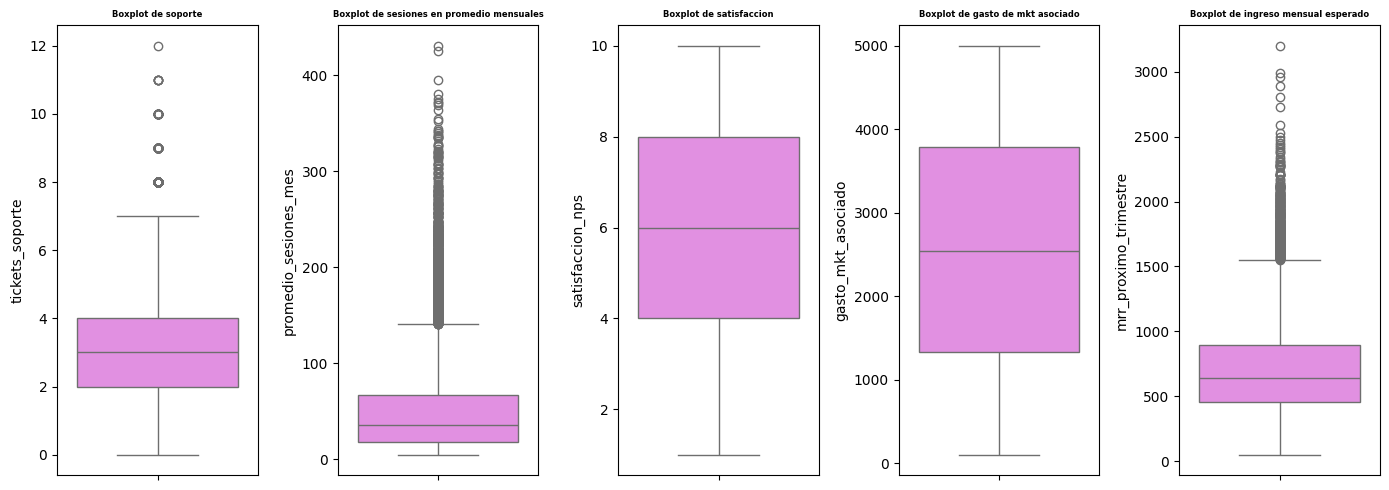

In [127]:
# 1. Generar Boxplots
fig, axes = plt.subplots(1, 5, figsize=(14, 5))

sns.boxplot(y=data["tickets_soporte"], ax=axes[0], color="violet")
axes[0].set_title("Boxplot de soporte", fontsize=6, fontweight="bold")

sns.boxplot(y=data["promedio_sesiones_mes"], ax=axes[1], color="violet")
axes[1].set_title("Boxplot de sesiones en promedio mensuales", fontsize=6, fontweight="bold")

sns.boxplot(y=data["satisfaccion_nps"], ax=axes[2], color="violet")
axes[2].set_title("Boxplot de satisfaccion", fontsize=6, fontweight="bold")


sns.boxplot(y=data["gasto_mkt_asociado"], ax=axes[3], color="violet")
axes[3].set_title("Boxplot de gasto de mkt asociado", fontsize=6, fontweight="bold")

sns.boxplot(y=data["mrr_proximo_trimestre"], ax=axes[4], color="violet")
axes[4].set_title("Boxplot de ingreso mensual esperado", fontsize=6, fontweight="bold")

plt.tight_layout()
plt.show()

Solo se observan valores atípicos en tickets_soporte, promedio_sesiones_mes y mrr_proximo_trimestre. Como mrr_proximo_trimestre es la variable objetivo, no se eliminaran los valores atípicos de esta variable.

# Fase 2: Limpieza y Tratamiento de Datos

## Winsorizer

In [128]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    X = pd.DataFrame(X)
    self.columns_ = X.columns
    self.lower_ = X.quantile(self.limits[0])
    self.upper_ = X.quantile(1 - self.limits[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_).astype("float64")
    return X.clip(lower=self.lower_, upper=self.upper_, axis=1)

  def get_feature_names_out(self, input_features=None):
    return np.array(self.columns_ if input_features is None else input_features)

Se limita la influencia de los atípicos

## Ingenieria de Datos

In [129]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
  """
  Ingeniería de características

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  fecha_referencia : str
    Fecha fija desde la que se mide la antigüedad del cliente.
  Returns
  -------
  DataFrame
    Conjunto de datos con nuevas características.
  """
  def __init__(self, fecha_referencia="2026-01-01"):
    self.fecha_referencia = fecha_referencia

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()
    # Antigüedad del cliente en días
    fecha = pd.to_datetime(X['fecha_registro'])
    X['antiguedad_dias'] = (pd.Timestamp(self.fecha_referencia) - fecha).dt.days

    # Mapeo numérico y binario
    X['duracion_contrato'] = X['duracion_contrato'].map({'Mensual': 0, 'Anual': 1, '2 Años': 2})
    X['pago_puntual'] = X['pago_puntual'].map({'No': 0, 'Si': 1})

    return X.drop(columns=['id_cliente', 'fecha_registro'])

## Recuperar los nombres de las tablas

In [130]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

In [131]:
# Numéricas con atípicos: winsorización + imputación con mediana + estandarización
outlier_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.01, 0.01))),
    ("imputer", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler())
])

# Numéricas sin atípicos: imputación con mediana + estandarización
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

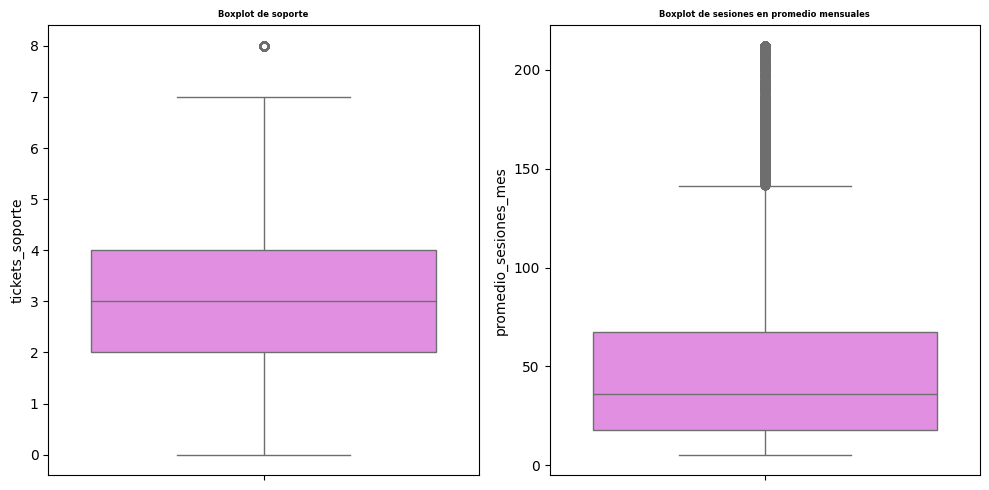

In [132]:
cols_outliers = ["tickets_soporte", "promedio_sesiones_mes"]

wins = Winsorizer(limits=(0.01, 0.01))
data_w = data.copy()
data_w[cols_outliers] = wins.fit_transform(data[cols_outliers])


# 1. Generar Boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(y=data_w["tickets_soporte"], ax=axes[0], color="violet")
axes[0].set_title("Boxplot de soporte", fontsize=6, fontweight="bold")

sns.boxplot(y=data_w["promedio_sesiones_mes"], ax=axes[1], color="violet")
axes[1].set_title("Boxplot de sesiones en promedio mensuales", fontsize=6, fontweight="bold")

plt.tight_layout()
plt.show()

Se winsoriza el 1% de cada extremo en **tickets_soporte** y **promedio_sesiones_mes**. La variable objetivo no se winsoriza. Este gráfico es ilustrativo: en el modelo, los límites se aprenden solo con el conjunto de entrenamiento.

In [133]:
# Se establece la variable objetivo

target = "mrr_proximo_trimestre"

## Matriz de relaciones variables cuantitativas

In [134]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación CON la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,mrr_proximo_trimestre
mrr_proximo_trimestre,1.000000
promedio_sesiones_mes,0.533780
satisfaccion_nps,0.157194
gasto_mkt_asociado,0.094029
tickets_soporte,-0.089306


El parámetro con una correlación más fuerte es promedio\_sesiones\_mes, luego vemos que satisfaccion\_nps tiene una correlación débil\. Los demás no presentan una gran influencia sobre la variable objetivo\.

## Ingreso mensual esperado

In [135]:
data.groupby("sector_empresa")[target].mean().sort_values(ascending=False)

,mrr_proximo_trimestre
sector_empresa,
Retail,724.811096
Salud,712.261938
Finanzas,708.909827
Tecnologia,708.652767
Educacion,699.089481


Ingreso mensual esperado por sector de la empresa\. Retail es el sector empresarial con mayor ingreso mensual esperado y educación tiene el menor\.

In [136]:
data.groupby("tamano_empresa")[target].mean().sort_values(ascending=False)

,mrr_proximo_trimestre
tamano_empresa,
Grande,1199.281085
Mediana,771.173538
Pequeña,516.366211


Ingreso mensual esperado por tamaño de la empresa\. Las empresas grandes tienen un mayor ingreso mensual esperado, mientras que las pequeñas tienen uno menor\.

In [137]:
data.groupby("duracion_contrato")[target].mean().sort_values(ascending=False)

,mrr_proximo_trimestre
duracion_contrato,
2 Años,908.228330
Anual,777.463822
Mensual,645.281958


Ingreso mensual esperado por tipo de suscripción\. Los contratos a 2 años tienden a traer un mayor ingreso mensual esperado, mientras que contratos mensuales no tanto\.

In [138]:
data.groupby("pago_puntual")[target].mean().sort_values(ascending=False)

,mrr_proximo_trimestre
pago_puntual,
Si,750.543111
No,549.510507


Ingreso mensual esperado por pago puntual\. Asi, los pagos puntuales tienden a un ingreso mensual más alto que aquellas empresas donde sus clientes no pagan puntualmente\.

## Matriz de relaciones variables cualitativas

In [139]:
columnas_cat = ["sector_empresa", "tamano_empresa", "duracion_contrato", "pago_puntual"]

encoder = OneHotEncoder(sparse_output=False)
cat_encoded = encoder.fit_transform(data[columnas_cat])

data_ohe = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data, data_ohe], axis=1)

data_corr.corr(numeric_only=True)[target]

,mrr_proximo_trimestre
tickets_soporte,-0.089306
promedio_sesiones_mes,0.533780
satisfaccion_nps,0.157194
gasto_mkt_asociado,0.094029
mrr_proximo_trimestre,1.000000
sector_empresa_Educacion,-0.011693
sector_empresa_Finanzas,-0.003457
sector_empresa_Retail,0.017352
sector_empresa_Salud,0.001981
sector_empresa_Tecnologia,-0.004377


Se calcula la correlación entre las variables con nuetro objetivo, separando las variables discretas en sus componentes gracias al one hot encoder\.

In [140]:
# Separación de variables
X = data.drop(columns=[target])
y = data[target]

# Nombres de columnas después de FeatureEngineering
outlier_features = ['tickets_soporte', 'promedio_sesiones_mes']
num_features = ['satisfaccion_nps', 'gasto_mkt_asociado', 'antiguedad_dias']
ord_features = ['tamano_empresa']
cat_features = ['sector_empresa']
# duracion_contrato y pago_puntual ya quedan mapeadas en FeatureEngineering

preprocessor = ColumnTransformer(
    transformers=[
        ("outliers", outlier_transformer, outlier_features),
        ("num", numeric_transformer, num_features),
        ("ord", OrdinalEncoder(categories=[["Pequeña", "Mediana", "Grande"]]), ord_features),
        ("cat", categorical_transformer, cat_features)
    ],
    remainder="passthrough"
)

print("Preprocesador configurado. Variables X e y separadas.")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Preprocesador configurado. Variables X e y separadas.
Dimensiones de X: (30000, 10)
Dimensiones de y: (30000,)


Se separan las pistas \("X"\) de las respuestas \("y"\) para evitar la memorizacion en el entrenamiento\.

Luego, se decide qué tratamientos hacer por cada variable\. A tickets\_soporte y promedio\_sesiones\_mes se les hará una winsorización, imputación con mediana y estandarizacion\. A satisfaccion\_nps, gasto\_mkt\_asociado y antiguedad\_dias se les aplica imputacion con mediana y estandarización\. A tamano\_empresa se le hace una codificacion en orden \(0, 1, 2\) y a sector\_empresa un one\-hot encoder\.

Finalmente se agrupan los resultados obtenidos en una sola tabla, así también columnas como duracion\_contrato y pago\_puntual no reciben ningún tratamiento\.

# Fase 3: Construcción del Modelo

## Dividir datos de entrenamiento y datos de prueba

In [141]:
# Crea el pipeline final (preprocesamiento + modelo)
modelo = Pipeline(steps=[
    ("feature_engineering", FeatureEngineering()),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("modelo", LinearRegression())
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

# Entrenamiento
modelo.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('feature_engineering', FeatureEngineering()),
                ('preprocesador',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('outliers',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer(limits=(0.01,
                                                                                      0.01))),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['tickets_soporte',
                                                   'promedio_sesiones_mes']),
                                                 ('num',
                                                  Pipeline(step...
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('escalado',
                                                                                                   StandardScaler())]),
                                                                                  ['satisfaccion_nps',
                                                                                   'gasto_mkt_asociado',
                                                                                   'antiguedad_dias']),
                                                                                 ('ord',
                                                                                  OrdinalEncoder(categories=[['Pequeña',
                                                                                                              'Mediana',
                                                                                                              'Grande']]),
                                                                                  ['tamano_empresa']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('onehot',
                                                                                                   OneHotEncoder(drop='first',
                                                                                                                 handle_unknown='ignore',
                                                                                                                 sparse_output=False))]),
                                                                                  ['sector_empresa'])]))),
                ('modelo', LinearRegression())])

Se encadenan 4 procesos que son para preparar la predicción\.

In [142]:
# Variables con las cuales fue entrenado el modelo
modelo.named_steps["conversion"].feature_names_

array(['outliers__tickets_soporte', 'outliers__promedio_sesiones_mes',
       'num__satisfaccion_nps', 'num__gasto_mkt_asociado',
       'num__antiguedad_dias', 'ord__tamano_empresa',
       'cat__sector_empresa_Finanzas', 'cat__sector_empresa_Retail',
       'cat__sector_empresa_Salud', 'cat__sector_empresa_Tecnologia',
       'remainder__duracion_contrato', 'remainder__pago_puntual'],
      dtype=object)

# Fase 4: Evaluación e Interpretación de Métricas:

In [143]:
y_pred_test = modelo.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"{'R2 en test':<20}: {r2:.3f}")
y_pred_train = modelo.predict(X_train)
print(f"{'R2 en train':<20}: {r2_score(y_train, y_pred_train):.3f}")

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"{'MAE en train':<20}: {mae_train:,.2f} USD")
print(f"{'MAE en test':<20}: {mae_test:,.2f} USD")
print(f"{'Diferencia':<20}: {mae_test - mae_train:,.2f} USD")

R2 en test          : 0.919
R2 en train         : 0.915
MAE en train        : 70.34 USD
MAE en test         : 69.03 USD
Diferencia          : -1.31 USD


Para verificar que el modelo no se limitó a memorizar los datos con los que fue entrenado, comparamos su error en dos grupos de clientes:

Clientes de entrenamiento (los que el modelo ya conocía -> set train): MAE de 70,34 USD.
Clientes de prueba (clientes nuevos que el modelo nunca vio -> set test): MAE de 69,03 USD.

La diferencia es de solo 1,31 USD. Es decir, el modelo se equivoca prácticamente lo mismo con clientes nuevos que con los que ya conocía.

Si el modelo hubiera memorizado los datos (sobreajuste u overfitting), su error en entrenamiento sería mucho menor que con clientes nuevos, y eso no ocurre. Tampoco hay subajuste (underfitting): el error es bajo en ambos grupos y el modelo explica el 92% de la variación del MRR (R² = 0,92). Que el error en prueba sea levemente menor se debe al azar en la división de los datos y no indica ningún problema.

Conclusión: el modelo generaliza bien y su precisión es confiable para proyectar el ingreso de clientes futuros.